# Finding the usable images in a satellite archive

*Screening 536 Sentinel-2 scenes for cloud in a few seconds, with PCA and DBSCAN, and
without labelling anything.*

**The problem.** To watch a reef change you need a dense time series, which means
deciding which of several hundred archived scenes are actually worth downloading.
The number everyone reaches for is the scene-level cloud percentage, and over water
it is a poor guide. 

**The idea.** Stop looking at pixels and look at whole images. Flatten each image into
one long vector, so that an archive of *n* scenes becomes *n* points in a
*d*-dimensional space, and run PCA over that. This is the opposite of the usual
remote-sensing use of PCA, which reduces the *band* dimension inside a single image.
Images of the same place under the same conditions land close together; cloud, glint
and colour-balance failures push a scene away from that cluster. Density-based
clustering then separates the two without anyone labelling anything.

**The data.** `thumbnails_55LCD.npy` holds 536 ESA Preview Images (PVI) for Sentinel-2
tile 55LCD, off Cairns on the Great Barrier Reef, 2015–2024. These are the free
quicklook JPEGs ESA generates for every product: subsampled B04/B03/B02 as true
colour, ~320 m/pixel. You can screen an entire archive from them before downloading
a single gigabyte. (Native size is 343×343; they are stored here at 128×128 so the
archive fits in a git repo — see `data/prepare_data.py`.)

536 images of shape (128, 128, 3), uint8


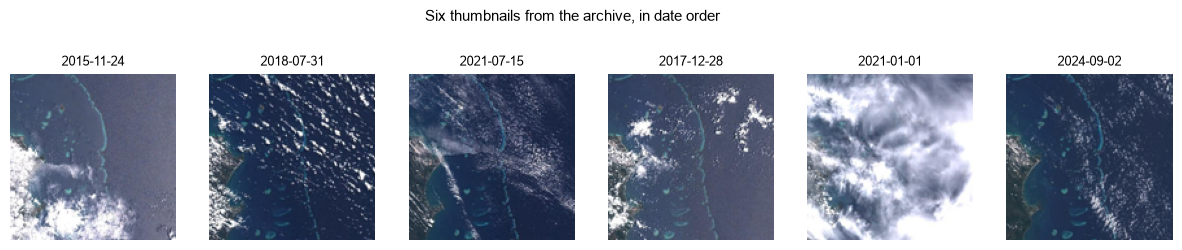

In [8]:
import time

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "legend.frameon": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
})

thumbnails = np.load("../data/thumbnails_55LCD.npy")
with open("../data/thumbnails_55LCD_filenames.txt") as f:
    dates = [f"{n[11:15]}-{n[15:17]}-{n[17:19]}" for n in f]
print(f"{len(thumbnails)} images of shape {thumbnails.shape[1:]}, {thumbnails.dtype}")

fig, axes = plt.subplots(1, 6, figsize=(15, 2.7))
for ax, i in zip(axes, np.linspace(0, len(thumbnails) - 1, 6).astype(int)):
    ax.imshow(thumbnails[i])
    ax.set_title(dates[i], fontsize=9)
    ax.axis("off")
fig.suptitle("Six thumbnails from the archive, in date order", y=1.04)
plt.show()

## Method

The whole of it is three steps. One image becomes one row; PCA keeps however many
components it takes to explain 95% of the variance; we use DBSCAN to group them.

DBSCAN is the what was used for clustering here because we dont always know how many clusters to expect (Particularly if there are numerous relative orbits capturing the same area), and it labels points that belong to no dense group as noise (`-1`) rather than forcing them into a cluster.

In [2]:
X = thumbnails.reshape(len(thumbnails), -1).astype(np.float32) / 255.0

start = time.perf_counter()
pca = PCA(n_components=0.95).fit(X)
pcs = pca.transform(X)
labels = DBSCAN(eps=19, min_samples=5).fit_predict(pcs)
elapsed = time.perf_counter() - start

print(f"{X.shape[1]} dimensions -> {pcs.shape[1]} components, in {elapsed:.1f} s")
for label, count in zip(*np.unique(labels, return_counts=True)):
    name = "noise" if label == -1 else f"cluster {label}"
    print(f"  {name:<10} {count:>4} images   mean brightness {X[labels == label].mean():.3f}")

49152 dimensions -> 185 components, in 1.9 s
  noise       362 images   mean brightness 0.480
  cluster 0   148 images   mean brightness 0.314
  cluster 1    26 images   mean brightness 0.986


### Choosing the clustering radius

`eps` is the neighbourhood radius, and it is the one parameter worth interrogating
rather than asserting. Two questions matter: where should it sit, and how much does it
matter if it sits somewhere else?

The left panel answers the first. Sorting every point's distance to its 5th-nearest
neighbour gives a curve whose knee marks the distance at which points stop being in
dense company; `eps = 19` sits on that knee. 

The right panel answers the second, by re-running the clustering across the whole range
of radii and tracking the clear cluster's size and its overlap with the choice made
here. There is no cliff: the cluster grows smoothly as the radius loosens, absorbing
borderline scenes from the partially-cloudy middle, `eps` is a strictness dial for what
counts as clear, not a value with a single right answer.

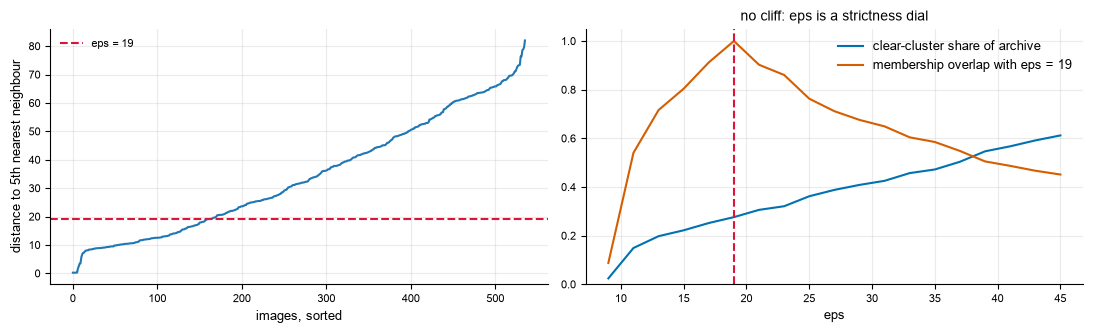

In [3]:
knn = NearestNeighbors(n_neighbors=5).fit(pcs)
kdist = np.sort(knn.kneighbors(pcs)[0][:, -1])


def clear_members(eps, min_share=0.02):
    """Darkest DBSCAN cluster holding at least min_share of the archive."""
    trial = DBSCAN(eps=eps, min_samples=5).fit_predict(pcs)
    big = [c for c in np.unique(trial) if c != -1 and (trial == c).mean() >= min_share]
    if not big:
        return set()
    darkest = min(big, key=lambda c: X[trial == c].mean())
    return set(np.where(trial == darkest)[0])


reference = clear_members(19)
radii = np.arange(9, 46, 2)
sweep = [clear_members(eps) for eps in radii]
share = [len(m) / len(X) for m in sweep]
overlap = [len(m & reference) / len(m | reference) for m in sweep]

fig, (a, b) = plt.subplots(1, 2, figsize=(11, 3.4))
a.plot(kdist)
a.axhline(19, color="crimson", ls="--", label="eps = 19")
a.set(xlabel="images, sorted", ylabel="distance to 5th nearest neighbour")
a.grid(alpha=0.25)
a.legend()
b.plot(radii, share, color="#0072B2", label="clear-cluster share of archive")
b.plot(radii, overlap, color="#D55E00", label="membership overlap with eps = 19")
b.axvline(19, color="crimson", ls="--")
b.set(xlabel="eps", ylim=(0, 1.05), title="no cliff: eps is a strictness dial")
b.grid(alpha=0.25)
b.legend(fontsize=9)
plt.tight_layout()
plt.show()


## Cluster structure of the archive

Clusters are ranked by mean brightness: darkest is clear sky, brightest is overcast.
No labels went into this — the ordering is a consequence of water being dark and cloud
being bright.

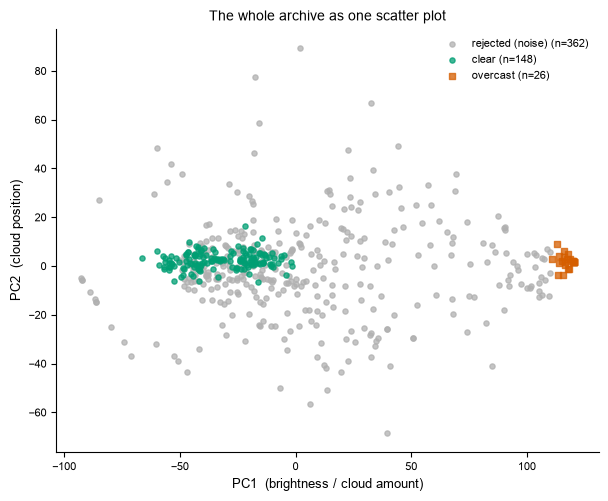

In [5]:
clusters = sorted((c for c in np.unique(labels) if c != -1),
                  key=lambda c: X[labels == c].mean())
names = {clusters[0]: "clear", clusters[-1]: "overcast"}
names.update({c: f"cluster {c}" for c in clusters[1:-1]})
names[-1] = "rejected (noise)"
# Colour pair chosen to stay separable under red-green colour blindness;
# the overcast cluster also gets its own marker shape as a second cue.
colours = {clusters[0]: "#009E73", clusters[-1]: "#D55E00", -1: "#b0b0b0"}
markers = {clusters[-1]: "s"}

plt.figure(figsize=(7, 5.5))
for label in [-1] + clusters:
    m = labels == label
    plt.scatter(pcs[m, 0], pcs[m, 1], s=14, alpha=0.75,
                c=colours.get(label, "#1f77b4"), marker=markers.get(label, "o"),
                label=f"{names[label]} (n={m.sum()})")
plt.xlabel("PC1  (brightness / cloud amount)")
plt.ylabel("PC2  (cloud position)")
plt.legend(frameon=False)
plt.title("The whole archive as one scatter plot")
plt.show()

The proof that the axes mean what the scatter plot claims is simply to look at the
images each group contains.

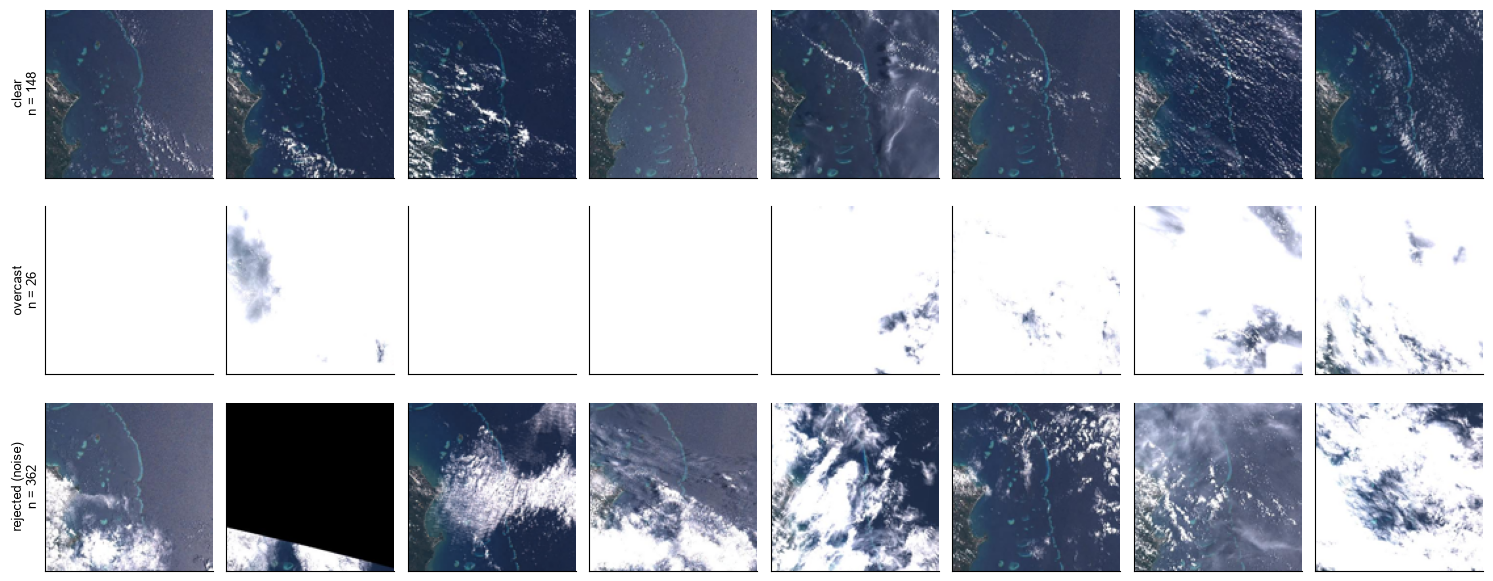

In [6]:
groups = [(names[clusters[0]], clusters[0]), (names[clusters[-1]], clusters[-1]),
          ("rejected (noise)", -1)]
fig, axes = plt.subplots(3, 8, figsize=(15, 6.2))
for row, (title, label) in zip(axes, groups):
    idx = np.where(labels == label)[0]
    for ax, i in zip(row, idx[np.linspace(0, len(idx) - 1, 8).astype(int)]):
        ax.imshow(thumbnails[i])
        ax.set_xticks([]); ax.set_yticks([])
    row[0].set_ylabel(f"{title}\nn = {len(idx)}", fontsize=9)
plt.tight_layout()
plt.show()

The middle row is what a cloud-percentage filter is good at: total write-offs, easy to
catch either way. The interesting row is the bottom one. "Noise" is not a failure of the
method, it is the partially-contaminated middle of the archive, thin cirrus, cloud over
one corner, an off colour balance. These are the scenes a 50% cloud threshold silently
throws away even when the reef itself is clear, and they are exactly the observations a
dense time series is short of. Manually reviewed against a 50% cloud threshold on this
tile, the approach recovered ~28 extra reef observations, an 11% gain, while also
rescuing ~16 clear scenes the threshold had wrongly excluded
(manual validation from [the paper this repository accompanies](https://www.mdpi.com/2072-4292/17/7/1244)).

## Inverse-transform validation

PCA is invertible, so the claim can be tested rather than argued. Fit a PCA to the clear
cluster alone, draw samples from a Gaussian fitted in that 2-D subspace, and invert them
back into images. If the subspace is genuinely free of atmosphere, its synthetic images
should look like plausible clear scenes; the same construction over the whole archive
should keep producing cloud.

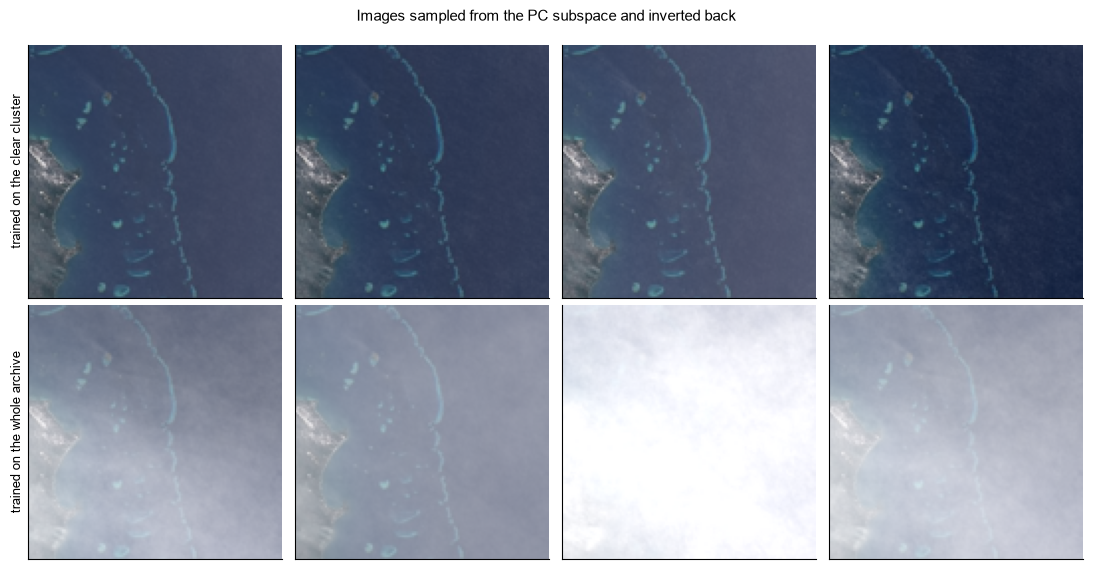

In [7]:
rng = np.random.default_rng(0)


def sample_subspace(rows, n=4):
    model = PCA(n_components=2).fit(rows)
    z = model.transform(rows)
    draws = rng.multivariate_normal(z.mean(0), np.cov(z.T), size=n)
    return model.inverse_transform(draws).reshape(n, *thumbnails.shape[1:])


fig, axes = plt.subplots(2, 4, figsize=(11, 5.8))
for row, (title, rows_) in zip(
    axes,
    [("trained on the clear cluster", X[labels == clusters[0]]),
     ("trained on the whole archive", X)],
):
    for ax, im in zip(row, sample_subspace(rows_)):
        ax.imshow(np.clip(im, 0, 1))
        ax.set_xticks([]); ax.set_yticks([])
    row[0].set_ylabel(title, fontsize=9)
fig.suptitle("Images sampled from the PC subspace and inverted back")
plt.tight_layout()
plt.show()

## Practical impact and limitations

A few seconds of CPU replaces a day of scrolling, and the result is a decision anyone can
re-run and get the same answer from. The screening happens on ~25 kB quicklooks, so it
runs *before* committing to downloads. You may need to use incremental PCA if RAM is limited on the machine you are using.

Three things it does not do. It assumes the darkest substantial cluster is the good one, which
fails in an archive where cloud dominates. It needs enough archive depth for the
components to be stable, a newly launched satellite with few images may not adhere to this. And it judges whole scenes, with enough imagery it is possible that the PC2 orientations tell you about cloud position.

That last gap is where the companion notebooks pick up:
[masking cloud and land per pixel](02_cloud_and_land_masking.ipynb), and then
[removing the depth signal](03_superpixel_depth_invariant_index.ipynb) from what is left.